In [1]:
import os
import pickle
import argparse
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_glue_results(experiment_path, epochs_per_task=None):
    config_path = os.path.join(experiment_path, "config.pkl")
    glue_path = os.path.join(experiment_path, "glue_metrics.pkl")
    
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Config file not found at {config_path}")
    if not os.path.exists(glue_path):
        raise FileNotFoundError(f"GLUE metrics file not found at {glue_path}")

    # Load configuration and metrics
    with open(config_path, 'rb') as f:
        config = pickle.load(f)
        
    with open(glue_path, 'rb') as f:
        full_results = pickle.load(f)

    figures_dir = os.path.join(experiment_path, "figures")
    os.makedirs(figures_dir, exist_ok=True)
    
    train_tasks = sorted(list(full_results.keys()))
    if not train_tasks:
        print("No GLUE data found to plot.")
        return

    first_eval_task = list(full_results[train_tasks[0]].keys())[0]
    metric_names = list(full_results[train_tasks[0]][first_eval_task].keys())
    
    # Setup subplots
    n_metrics = len(metric_names)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(12, 3 * n_metrics), sharex=True)
    if n_metrics == 1: 
        axes = [axes]
    
    # Initialize timeline storage
    timeline = {m: {} for m in metric_names}
    task_boundaries = []
    
    # Safely pull exact training lengths
    log_frequency = getattr(config, 'log_frequency', 10)
    
    if epochs_per_task is None:
        epochs_per_task = getattr(config, 'epochs_per_task', 1000)
        
    L = epochs_per_task // log_frequency
    sampled_steps = [0, 2, 5, L-1] # The exact indices used in run_representation_analysis.py
    dataset_name = getattr(config, 'dataset_name', 'Dataset')

    # Helper function to warp relative epochs to a log scale within the task window
    def warp_epoch(task_index, rel_epoch, total_task_epochs):
        if rel_epoch == 0:
            return task_index * total_task_epochs
        # Maps [0, total_task_epochs] to [0, total_task_epochs] logarithmically
        warped_rel = (np.log(rel_epoch + 1) / np.log(total_task_epochs + 1)) * total_task_epochs
        return (task_index * total_task_epochs) + warped_rel
    
    global_x_true = []
    global_x_warped = []

    for t_train_idx, t_train in enumerate(train_tasks):
        eval_tasks_in_train = list(full_results[t_train].keys())
        if not eval_tasks_in_train:
            continue
            
        # Calculate true absolute epoch numbers
        start_epoch = t_train_idx * epochs_per_task
        
        task_epochs_true = [start_epoch + (s * log_frequency) for s in sampled_steps]
        task_epochs_warped = [warp_epoch(t_train_idx, s * log_frequency, epochs_per_task) for s in sampled_steps]
        
        global_x_true.extend(task_epochs_true)
        global_x_warped.extend(task_epochs_warped)
        
        task_boundaries.append(start_epoch + epochs_per_task)
        
        # Aggregate data for each evaluated task
        for t_eval in eval_tasks_in_train:
            for m in metric_names:
                if t_eval not in timeline[m]:
                    timeline[m][t_eval] = {'mean': [], 'std': []}
                    
                data = full_results[t_train][t_eval][m]
                
                # Average across Repeats (axis 1)
                mean = np.nanmean(data, axis=1)
                std = np.nanstd(data, axis=1)
                
                # Use extend instead of append to flatten the list as we go
                timeline[m][t_eval]['mean'].extend(mean)
                timeline[m][t_eval]['std'].extend(std)

    global_x_true = np.array(global_x_true)
    global_x_warped = np.array(global_x_warped)

    all_eval_tasks = sorted(list(timeline[metric_names[0]].keys()))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(all_eval_tasks))))
    
    # Plotting loop
    for i, metric in enumerate(metric_names):
        ax = axes[i]
        
        for j, t_eval in enumerate(all_eval_tasks):
            full_mean = np.array(timeline[metric][t_eval]['mean'])
            full_std = np.array(timeline[metric][t_eval]['std'])
            
            if len(full_mean) == 0: continue
            
            # Plot using the WARPED epoch coordinates
            ax.plot(global_x_warped, full_mean, label=t_eval, color=colors[j], linewidth=2, marker='o', markersize=4)
            ax.fill_between(global_x_warped, 
                            full_mean - full_std, 
                            full_mean + full_std, 
                            color=colors[j], alpha=0.1)

        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        
        # Draw vertical lines for task boundaries
        for boundary in task_boundaries[:-1]:
            ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.5, linewidth=1.5)

        if i == 0:
            ax.set_title(f"GLUE Metrics Analysis (Sparse Evaluation) - {dataset_name}")
            ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title="Evaluated Task")

    # Set custom ticks so the labels display the true epochs at the warped positions
    axes[-1].set_xticks(global_x_warped)
    axes[-1].set_xticklabels([str(int(x)) for x in global_x_true], rotation=45, ha='right')
    
    axes[-1].set_xlabel('Epochs (Log-scaled within each task boundary)')
    plt.tight_layout()
    plt.show()

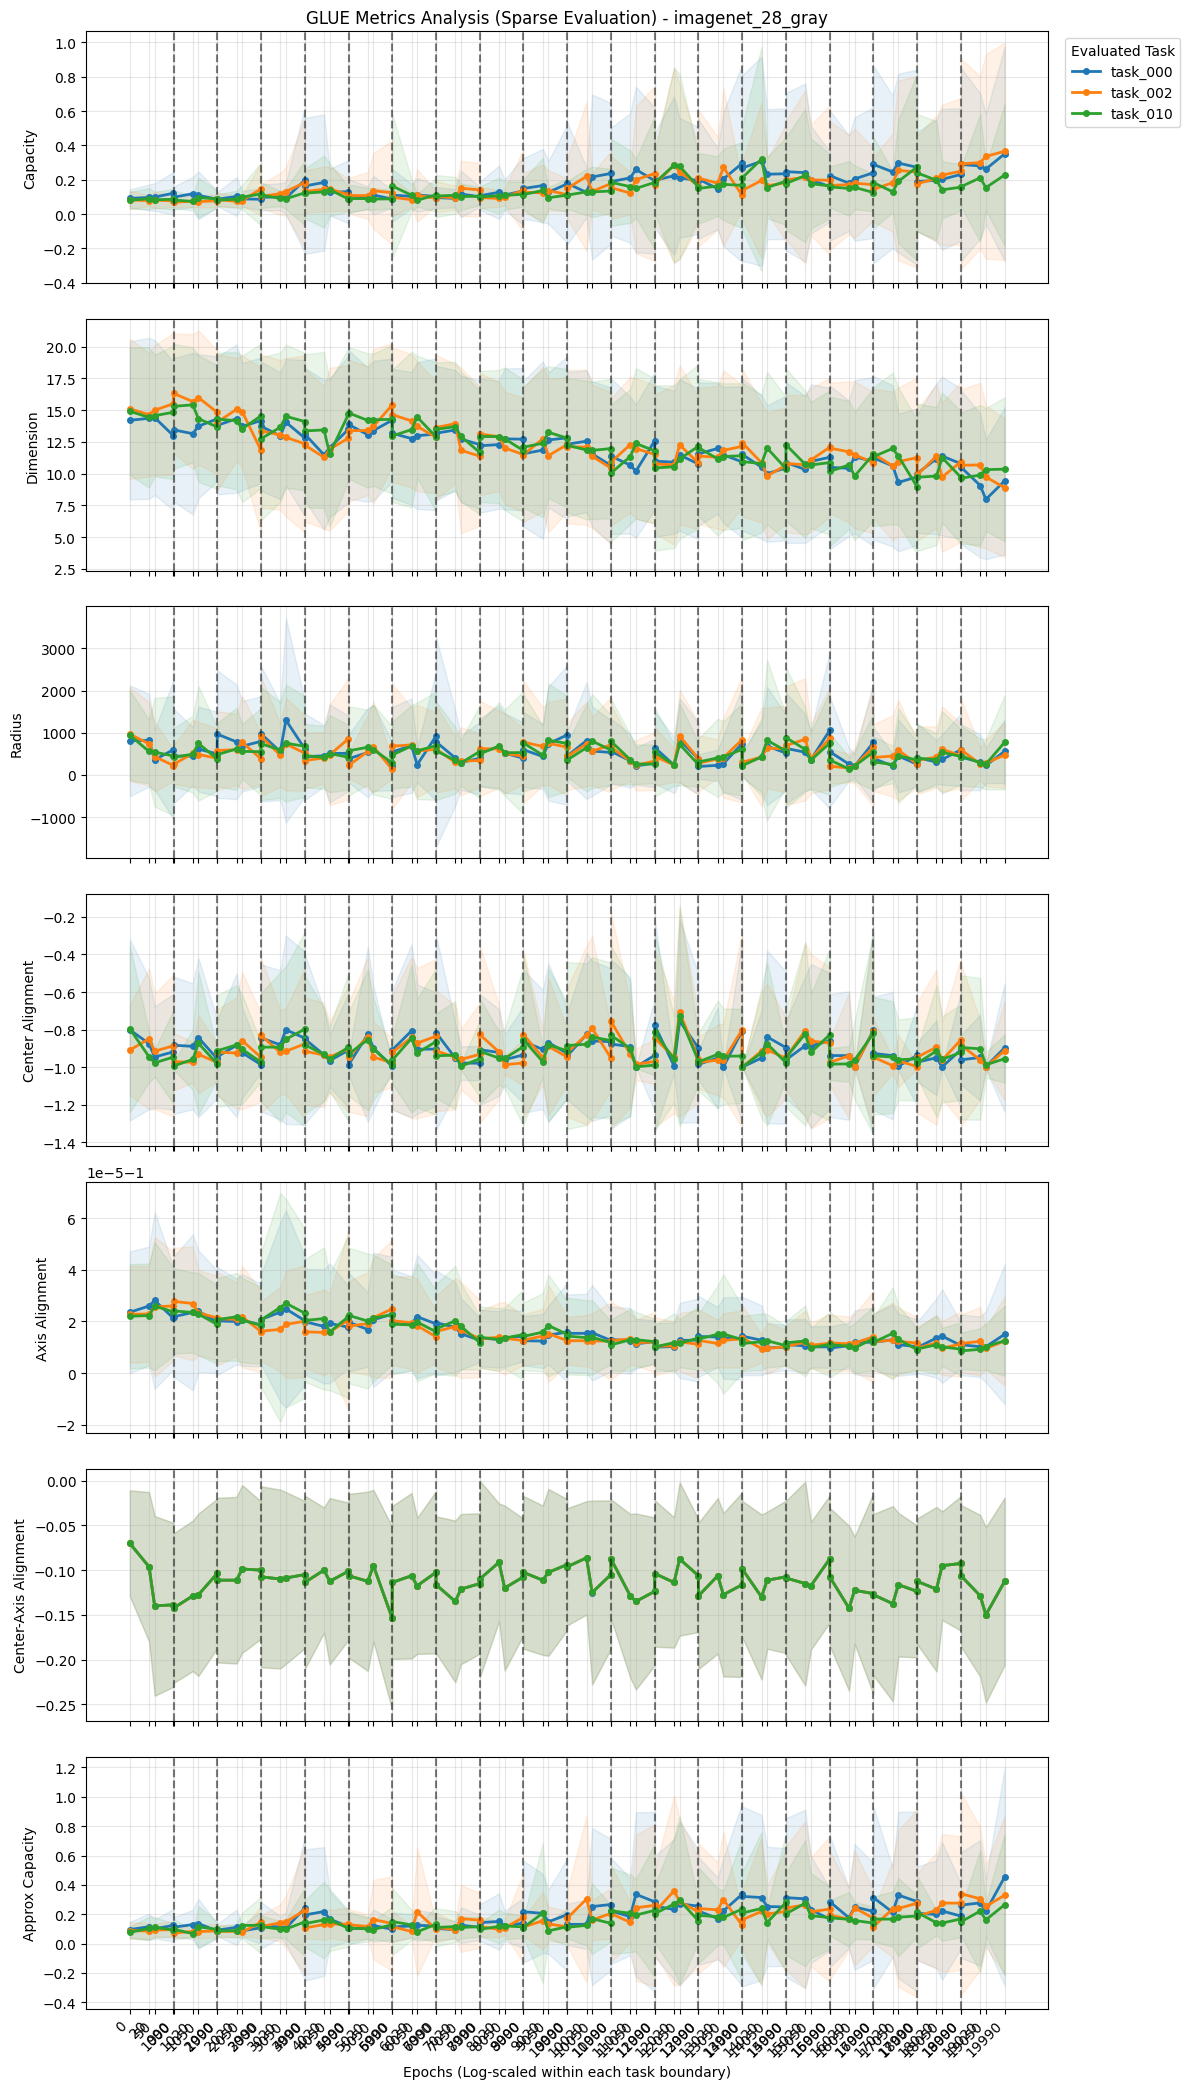

In [3]:
experiment_path = "/home/users/MTrappett/manifold/binary_classification/results/imagenet_28_gray/SL_20_tasks_lr1_0.0001_lr2_0.01"
plot_glue_results(experiment_path)